In [6]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

In [7]:
DATA_DIR = Path("../data/split")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

LOAD DATASET

In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

Found 5396 files belonging to 6 classes.


Fungsi CLAHE

In [9]:
def apply_clahe(image):

    image = image.numpy().astype(np.uint8)

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    enhanced_lab = cv2.merge(
        (cl,a,b)
    )

    enhanced_rgb = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced_rgb

Fungsi Gaussian

In [10]:
def apply_gaussian(image):

    image = np.array(image).astype(np.uint8)

    return cv2.GaussianBlur(
        image,
        (3,3),
        0
    )

Clahe + Gaussian

In [11]:
def apply_clahe_gaussian(image):

    clahe_result = apply_clahe(image)

    gaussian_result = apply_gaussian(
        clahe_result
    )

    return gaussian_result

Data Sample

In [12]:
for images, labels in train_dataset.take(1):

    sample_image = images[3]

    break

Histogram sebelum dan Sesudah CLAHE

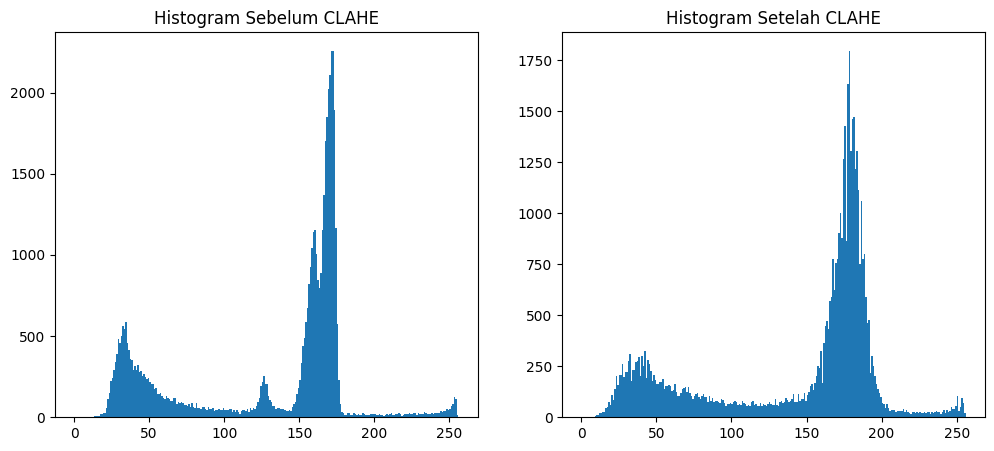

In [13]:
original = sample_image.numpy().astype(np.uint8)

clahe_image = apply_clahe(sample_image)

gray_original = cv2.cvtColor(
    original,
    cv2.COLOR_RGB2GRAY
)

gray_clahe = cv2.cvtColor(
    clahe_image,
    cv2.COLOR_RGB2GRAY
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.hist(
    gray_original.ravel(),
    bins=256,
    range=(0,256)
)

plt.title("Histogram Sebelum CLAHE")

plt.subplot(1,2,2)

plt.hist(
    gray_clahe.ravel(),
    bins=256,
    range=(0,256)
)

plt.title("Histogram Setelah CLAHE")

plt.show()

In [14]:
print("=== ORIGINAL ===")

print("Min :", gray_original.min())
print("Max :", gray_original.max())
print("Mean:", gray_original.mean())
print("Std :", gray_original.std())

print()

print("=== CLAHE ===")

print("Min :", gray_clahe.min())
print("Max :", gray_clahe.max())
print("Mean:", gray_clahe.mean())
print("Std :", gray_clahe.std())

=== ORIGINAL ===
Min : 7
Max : 255
Mean: 130.8263313137755
Std : 57.58975163347453

=== CLAHE ===
Min : 2
Max : 255
Mean: 142.97046396683675
Std : 58.21910040953222


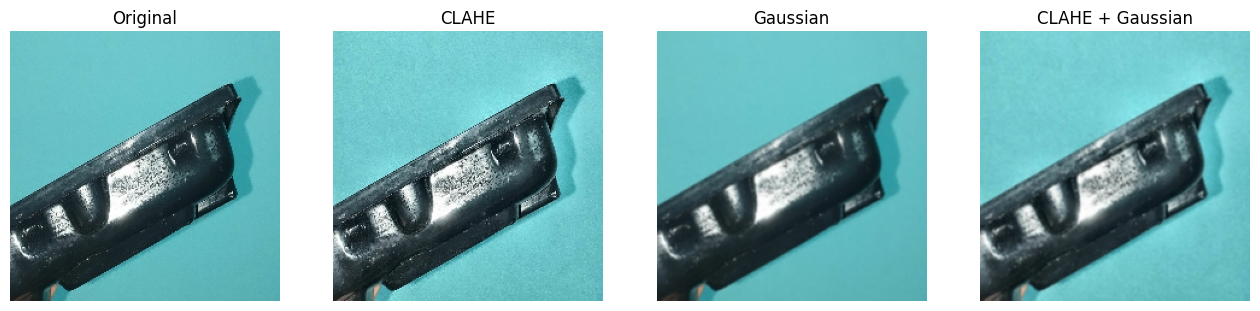

In [15]:
clahe_img = apply_clahe(sample_image)

gaussian_img = apply_gaussian(
    original
)

clahe_gaussian_img = apply_clahe_gaussian(
    sample_image
)

plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(clahe_img)
plt.title("CLAHE")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gaussian_img)
plt.title("Gaussian")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(clahe_gaussian_img)
plt.title("CLAHE + Gaussian")
plt.axis("off")

plt.show()


Save as New Dataset

In [16]:
from pathlib import Path

ENHANCED_DIR = Path("../data/enhanced")

CLAHE_DIR = ENHANCED_DIR / "clahe"

GAUSSIAN_DIR = ENHANCED_DIR / "gaussian"

CLAHE_GAUSSIAN_DIR = (
    ENHANCED_DIR / "clahe_gaussian"
)

In [17]:
def apply_clahe_array(image):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    merged = cv2.merge(
        (l,a,b)
    )

    result = cv2.cvtColor(
        merged,
        cv2.COLOR_LAB2RGB
    )

    return result

In [18]:
def apply_clahe_gaussian_array(image):

    image = apply_clahe_array(
        image
    )

    image = cv2.GaussianBlur(
        image,
        (3,3),
        0
    )

    return image

In [19]:
def process_and_save_dataset(
    source_dir,
    destination_dir,
    enhancement_function
):

    source_dir = Path(source_dir)

    destination_dir = Path(
        destination_dir
    )

    for class_folder in source_dir.iterdir():

        if not class_folder.is_dir():
            continue

        print(
            f"Processing {class_folder.name}"
        )

        for image_path in class_folder.glob("*"):

            image = cv2.imread(
                str(image_path)
            )

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )

            enhanced = enhancement_function(
                image
            )

            save_path = (
                destination_dir
                / class_folder.name
                / image_path.name
            )

            enhanced = cv2.cvtColor(
                enhanced,
                cv2.COLOR_RGB2BGR
            )

            cv2.imwrite(
                str(save_path),
                enhanced
            )

    print(
        f"Finished: {destination_dir}"
    )

In [20]:
process_and_save_dataset(
    TRAIN_DIR,
    CLAHE_DIR / "train",
    apply_clahe_array
)

process_and_save_dataset(
    VAL_DIR,
    CLAHE_DIR / "val",
    apply_clahe_array
)

process_and_save_dataset(
    TEST_DIR,
    CLAHE_DIR / "test",
    apply_clahe_array
)

Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\clahe\train
Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\clahe\val
Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\clahe\test


In [21]:
process_and_save_dataset(
    TRAIN_DIR,
    GAUSSIAN_DIR / "train",
    apply_gaussian
)

process_and_save_dataset(
    VAL_DIR,
    GAUSSIAN_DIR / "val",
    apply_gaussian
)

process_and_save_dataset(
    TEST_DIR,
    GAUSSIAN_DIR / "test",
    apply_gaussian
)

Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\gaussian\train
Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\gaussian\val
Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\gaussian\test


In [22]:
process_and_save_dataset(
    TRAIN_DIR,
    CLAHE_GAUSSIAN_DIR / "train",
    apply_clahe_gaussian_array
)

process_and_save_dataset(
    VAL_DIR,
    CLAHE_GAUSSIAN_DIR / "val",
    apply_clahe_gaussian_array
)

process_and_save_dataset(
    TEST_DIR,
    CLAHE_GAUSSIAN_DIR / "test",
    apply_clahe_gaussian_array
)

Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\clahe_gaussian\train
Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\clahe_gaussian\val
Processing biological
Processing cardboard
Processing glass
Processing metal
Processing paper
Processing plastic
Finished: ..\data\enhanced\clahe_gaussian\test
